In [1]:
%load_ext autoreload
%autoreload 2

import os
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from utils import readQuotes, MEDIAN, ATR, EMA, PERCENTILE, calculate_linear_regression_rolling

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
ticker = 'PLZL'
df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1W_history.txt')
df = df_base#.loc['2025-05-01 07:00:00':'2025-06-30 23:00:00',:].copy()

In [4]:
# Чтение индекса мосбиржи
ticker='IMOEX'
df_base = readQuotes(f'..\download_data\_{ticker}\{ticker}_1D_history.txt')
df_index = df_base

In [5]:
df_index['linear'] = calculate_linear_regression_rolling(df_index, period=60)
df_index['median'] = MEDIAN(df_index['close'], period=30)

In [6]:
tiсkers = []
with open('../download_data/temp.txt', 'r') as file:
    for t in file.readlines():
        t = t[:-1]  # отрываем символ переноса строки
        tiсkers.append(t)

In [7]:
df_by_ticker = dict()
for ticker in tiсkers:
    try:
        df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1W_history.txt')
        df_by_ticker[ticker] = df_base
    except Exception:
        print(ticker)

In [64]:
def intervals(start_date: datetime, step: timedelta):
    result = start_date + step
    
    return result

In [65]:
intervals(start_date=datetime(2025, 8, 21), step=timedelta(days=7))

datetime.datetime(2025, 8, 28, 0, 0)

In [66]:
from typing import Dict


def best_n_by_last_week(
    data: Dict[str, pd.DataFrame],
    strt_period:datetime,
    end_period: datetime,
    n: int = 1,
    shift:int = 0,
):
    storage = dict()
    for k, v in data.items():
        into_df = v.loc[strt_period:end_period].copy()
        if len(into_df) > 0:
            change_prc = round((into_df.iloc[-1].close - into_df.iloc[0].open) / into_df.iloc[0].open * 100, 2)
            storage[k] = change_prc

    storage = sorted(storage.items(), key=lambda x: x[1], reverse=True)
    cnt_positivе_prc = len(list(filter(lambda x: x[1]>0, storage)))

    result = {item[0]: item[1] for item in storage[shift:n+shift]}
    return result, round(cnt_positivе_prc/len(storage)*100, 1)

In [18]:
def range_df(start: datetime, stop:datetime, step: timedelta):
    if start > stop:
        return
    while start < stop:
        yield start
        start = start + step


In [19]:
import pandas as pd
from datetime import datetime, timedelta
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt


# Класс для управления портфелем
class Portfolio:
    def __init__(self, initial_capital: float = 100000, max_positions: int = 2):
        self.capital = initial_capital
        self.positions = {}  # {ticker: {'entry_price': float, 'quantity': int, 'stop_loss': float}}
        self.transaction_history = []
        self.equity_curve = []
        self.max_positions = max_positions
        
    def buy(self, ticker: str, price: float, stop_loss_pct: float, date: datetime):
        """Покупка акции с установкой стоп-лосса"""
        if self.capital <= 0:
            return False
        
        if self.positions.get(ticker, None):
            # print('Есть такая позициям', self.positions.keys())
            return False
        
        if len(self.positions) > self.max_positions:
            # print('Максимум по позициям')
            return False
            
        # Равномерное распределение капитала
        position_size = self.capital / 2 / self.max_positions  #  1/8 на сделку от половины капитала 
        quantity = int(position_size / price)
        
        if quantity <= 0:
            return False
            
        cost = quantity * price
        stop_loss = price * (1 - stop_loss_pct / 100)
        
        self.positions[ticker] = {
            'entry_price': price,
            'quantity': quantity,
            'stop_loss': stop_loss,
            'entry_date': date
        }
        self.capital -= cost
        
        self.transaction_history.append({
            'date': date,
            'action': 'BUY',
            'ticker': ticker,
            'price': price,
            'quantity': quantity,
            'cost': cost
        })
        
        return True
    
    def sell(self, ticker: str, price: float, date: datetime, reason: str = ''):
        """Продажа акции"""
        if ticker not in self.positions:
            return False
            
        position = self.positions[ticker]
        revenue = position['quantity'] * price
        pnl = revenue - (position['quantity'] * position['entry_price'])
        pnl_pct = (price / position['entry_price'] - 1) * 100
        
        self.capital += revenue
        del self.positions[ticker]
        
        self.transaction_history.append({
            'date': date,
            'action': 'SELL',
            'ticker': ticker,
            'price': price,
            'quantity': position['quantity'],
            'revenue': revenue,
            'pnl': pnl,
            'pnl_pct': pnl_pct,
            'reason': reason
        })
        
        return pnl_pct > 0
    
    def check_stop_losses(self, current_prices: Dict[str, float], date: datetime):
        """Проверка срабатывания стоп-лоссов"""
        tickers_to_sell = {}
        
        for ticker, position in self.positions.items():
            if ticker in current_prices:
                current_price = current_prices[ticker]
                if current_price <= position['stop_loss']:
                    tickers_to_sell[ticker] = position['stop_loss']
                    # self.sell(ticker, position['stop_loss'], date, 'Stop loss')
                    # tickers_to_sell.append(ticker)
        
        results = []
        for ticker, loss_price in tickers_to_sell.items():
            result = self.sell(ticker, loss_price, date, 'Stop loss')
            results.append(ticker)
        
        return results
    
    def get_total_value(self, current_prices: Dict[str, float]):
        """Общая стоимость портфеля"""
        portfolio_value = self.capital
        for ticker, position in self.positions.items():
            if ticker in current_prices:
                portfolio_value += position['quantity'] * current_prices.get(ticker, position['entry_price'])
        return portfolio_value


In [20]:
for i in range(1,8):
    print(i, 7/i)

1 7.0
2 3.5
3 2.3333333333333335
4 1.75
5 1.4
6 1.1666666666666667
7 1.0


In [120]:
def riseLinear(df):
    # cur = df[0]
    # counter = 0
    # for i in df[1:]:
    #     if i > cur:
    #         cur = i
    #         counter += 1
    # return counter
    # print(df)

    # # нормально если linear передать
    # if df[0] < df[1] < df[2]:
    #     return 10
    # return 0

    counter = 0
    for i in range(0, len(df)):
        if df.iloc[i]['close'] > df.iloc[i]['median']:
            counter += 1
    
    # if counter >= 4:
    #     return 10
    # return 0

    if counter > 0 and len(df) / counter < 1.26:
        return 10
    return 0



riseLinear(
    df_index.loc[datetime(2024, 4, 4):datetime(2024, 4, 17)]#['linear'].iloc[-3:]
)
# df_index.loc[datetime(2024, 9, 12):datetime(2024, 9, 19)]['linear']

10

In [ ]:
def test_strategy(
    initial_capital: int=10000,
    s=datetime(2025, 7, 3),
    e=datetime(2025, 7, 31),
    n_tickers:int=3,
    loss:float=3,
    min_market_rate:float=30,
    best_shift:int=0,
    n_step: int = 7 # недельный цикл
):
    eqv = []
    dates_eqv = []
    portfolio = Portfolio(initial_capital=initial_capital, max_positions=n_tickers)
    for dt in range_df(s, e, timedelta(days=n_step)):
        try:
            # период до текущего
            prev_start_period = intervals(start_date=dt, step=timedelta(days=-n_step))
            prev_start_period = prev_start_period.strftime('%Y-%m-%d')
            prev_end_period = intervals(start_date=dt, step=timedelta(days=-1))
            prev_end_period = prev_end_period.strftime('%Y-%m-%d')
            # print(f'prev period {prev_start_period} - {prev_end_period}')

            # период текущий
            start_period = dt
            end_period = intervals(start_date=start_period, step=timedelta(days=n_step-1))
            start_period = start_period.strftime('%Y-%m-%d')
            end_period = end_period.strftime('%Y-%m-%d')
            # print(f'curr period {start_period} - {end_period}')

            # определяем лучшие бумаги до текущего периода
            best_tickers, market_rate = best_n_by_last_week(
                df_by_ticker,
                prev_start_period,
                prev_end_period,
                n_tickers,
                shift=best_shift,
            )

            # оценка индекса
            rise_count = riseLinear(
                df_index.loc[prev_start_period:prev_end_period]
            )
            if rise_count < 4:
                tickers_in_porfolio = list(portfolio.positions.keys())
                for t in tickers_in_porfolio:
                    sell_price = df_by_ticker[t].loc[start_period].open
                    portfolio.sell(t, sell_price, start_period, 'Index down')
                eqv.append(portfolio.get_total_value({}))
                dates_eqv.append(start_period)
                continue
            
            # экстренная продажа
            if market_rate < min_market_rate:
                tickers_in_porfolio = list(portfolio.positions.keys())
                for t in tickers_in_porfolio:
                    #if t not in best_tickers:
                    sell_price = df_by_ticker[t].loc[start_period].open
                    portfolio.sell(t, sell_price, start_period, 'Black swan')
                eqv.append(portfolio.get_total_value({}))
                dates_eqv.append(start_period)
                continue

            #print(best_tickers)
            tickers_in_porfolio = list(portfolio.positions.keys())
            for t in tickers_in_porfolio:
                if t not in best_tickers:
                    sell_price = df_by_ticker[t].loc[start_period].open
                    portfolio.sell(t, sell_price, start_period, 'Not best')

            # цены в текущем периоде для лучших бумаг из прошлого периода
            minimum_prices={}
            open_prices = {}
            for ticker, rate in best_tickers.items():
                vals = df_by_ticker[ticker].loc[start_period:end_period]
                open = vals.iloc[0].open
                close = vals.iloc[-1].close
                low = min(vals.low)
                r = portfolio.buy(ticker, open, loss, start_period)
                minimum_prices[ticker] = low
                open_prices[ticker] = open
                # print(f'{ticker} o-{open} c-{close}, l-{low}', r)
            #print(minimum_prices)
            portfolio.check_stop_losses(minimum_prices, end_period)
            # print(portfolio.get_total_value(open_prices))
            eqv.append(portfolio.get_total_value(open_prices))
            dates_eqv.append(start_period)
            # print('-----------------')
            # if r:
            #     print(f'{dt} - {end_period}', f'{c}%', r)
        except Exception as err:
            print(f'{err=}')
        
    try:
        eqv.append(portfolio.get_total_value(open_prices))
        dates_eqv.append(start_period)
    except:
        pass
    return portfolio, eqv, dates_eqv

In [ ]:
# p, eqv4 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     4,
#     loss=4,
# )
# p, eqv5 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     5,
#     loss=4,
# )
# p, eqv6 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     6,
#     loss=4,
# )
# p, eqv7 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     7,
#     loss=4,
# )
# p, eqv8 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     8,
#     loss=4,
# )
# p, eqv9 = test_strategy(
#     datetime(2021, 1, 7),
#     datetime(2025, 7, 31),
#     9,
#     loss=4,
# )


# p, eqv7, date7 = test_strategy(
#     initial_capital=100000,
#     s=datetime(2021, 1, 7),
#     e=datetime(2025, 8, 31),
#     n_tickers=8,
#     loss=5,
#     min_market_rate=25,
#     best_shift=2,
#     n_step=19
# )

# p, eqv73, date73 = test_strategy(
#     initial_capital=100000,
#     s=datetime(2021, 1, 7),
#     e=datetime(2025, 8, 31),
#     n_tickers=8,
#     loss=5,
#     min_market_rate=25,
#     best_shift=2,
#     n_step=14
# )
# p, eqv71, date71 = test_strategy(
#     initial_capital=100000,
#     s=datetime(2021, 1, 7),
#     e=datetime(2025, 8, 31),
#     n_tickers=8,
#     loss=5,
#     min_market_rate=25,
#     best_shift=2,
#     n_step=10
# )

# лучший
p, eqv70, date70 = test_strategy(
    initial_capital=100000,
    s=datetime(2021, 1, 7),
    e=datetime(2025, 8, 31),
    n_tickers=8,
    loss=5,
    min_market_rate=25,
    best_shift=2,
    n_step=7
)

err=KeyError('2021-05-01')
err=KeyError('2021-06-27')
err=KeyError('2021-09-11')
err=ZeroDivisionError('division by zero')
err=KeyError('2022-12-11')
err=KeyError('2023-02-25')
err=KeyError('2023-04-23')
err=KeyError('2023-07-08')
err=KeyError('2023-09-03')
err=KeyError('2023-11-18')
err=KeyError('2024-05-26')
err=KeyError('2025-02-16')
err=ZeroDivisionError('division by zero')
err=KeyError('2024-05-09')
err=KeyError('2021-03-28')
err=KeyError('2021-04-17')
err=KeyError('2021-06-06')
err=KeyError('2021-06-26')
err=KeyError('2021-09-04')
err=KeyError('2021-10-24')
err=ZeroDivisionError('division by zero')
err=ZeroDivisionError('division by zero')
err=KeyError('2023-03-18')
err=KeyError('2023-05-07')
err=KeyError('2023-05-27')
err=KeyError('2023-07-16')
err=KeyError('2023-08-05')
err=KeyError('2024-02-11')
err=KeyError('2024-03-02')
err=KeyError('2024-04-21')
err=KeyError('2024-05-01')
err=KeyError('2024-05-11')
err=KeyError('2025-01-26')
err=KeyError('2025-02-15')
err=KeyError('2021-11-

In [136]:
len(date7)

79

''

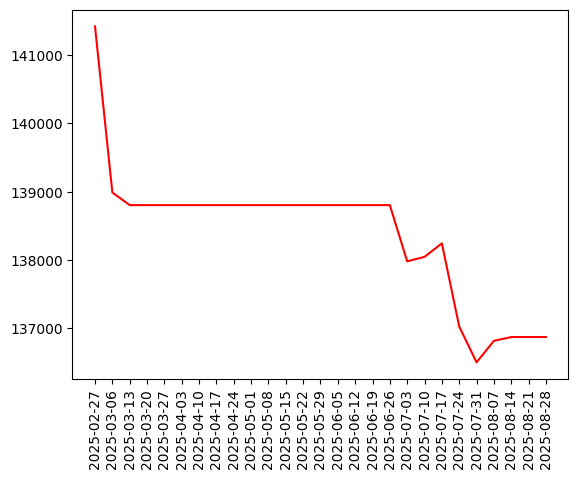

In [ ]:
import matplotlib.pyplot as plt

st = 200
en = 228
plt.plot(date7[st:en], eqv7[st:en], color='red')
plt.xticks(rotation=90)
;

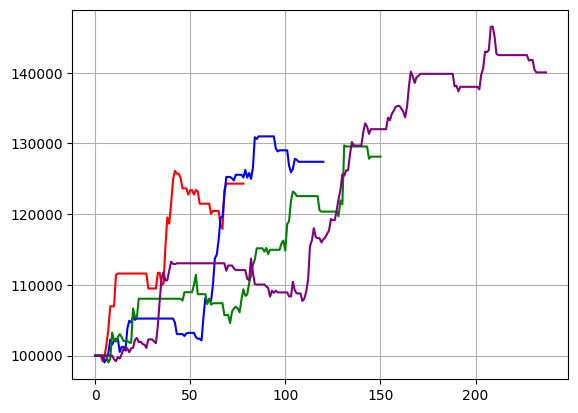

In [137]:
import matplotlib.pyplot as plt

plt.plot(eqv7, color='red')
plt.plot(eqv73, color='blue')
plt.plot(eqv71, color='green')
plt.plot(eqv70, color='purple')
# plt.plot(eqv8, color='orange')
plt.grid(True)

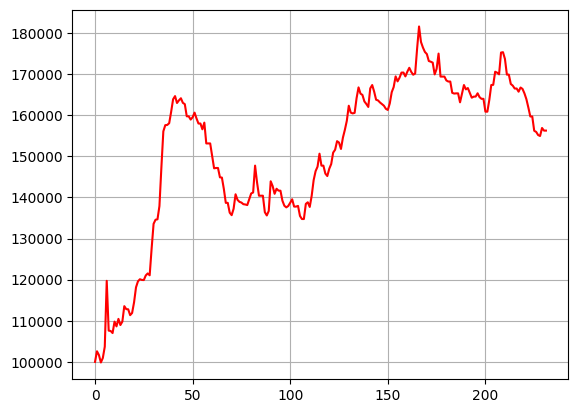

In [65]:
import matplotlib.pyplot as plt

plt.plot(eqv10, color='red')
# plt.plot(eqv9, color='blue')
# plt.plot(eqv11, color='green')
# plt.plot(eqv12, color='purple')
# plt.plot(eqv8, color='orange')
plt.grid(True)

In [531]:
p.get_total_value({
    'SELG': 46.89,
    'IVAT': 147.05,
    'RTKMP': 64.5,
    'CBOM': 6.899,
    'ENPG': 435.5,
    'RUAL': 31.695,
    'GMKN': 118.18,
    'ENPG': 435.5,
    'RAGR': 105.34
    })

125199.40671999994

In [491]:
p.transaction_history[5:]

[{'date': '2025-07-10',
  'action': 'BUY',
  'ticker': 'BELU',
  'price': 443.0,
  'quantity': 22,
  'cost': 9746.0},
 {'date': '2025-07-10',
  'action': 'BUY',
  'ticker': 'VKCO',
  'price': 303.3,
  'quantity': 32,
  'cost': 9705.6},
 {'date': '2025-07-17',
  'action': 'SELL',
  'ticker': 'PIKK',
  'price': 649.9,
  'quantity': 16,
  'revenue': 10398.4,
  'pnl': 712.0,
  'pnl_pct': 7.350512058143366,
  'reason': 'Not best'},
 {'date': '2025-07-17',
  'action': 'SELL',
  'ticker': 'BELU',
  'price': 426.5,
  'quantity': 22,
  'revenue': 9383.0,
  'pnl': -363.0,
  'pnl_pct': -3.724604966139955,
  'reason': 'Not best'},
 {'date': '2025-07-17',
  'action': 'BUY',
  'ticker': 'SELG',
  'price': 46.89,
  'quantity': 213,
  'cost': 9987.57},
 {'date': '2025-07-17',
  'action': 'BUY',
  'ticker': 'SVCB',
  'price': 17.05,
  'quantity': 586,
  'cost': 9991.300000000001},
 {'date': '2025-07-24',
  'action': 'SELL',
  'ticker': 'VKCO',
  'price': 331.2,
  'quantity': 32,
  'revenue': 10598.4,
 

In [500]:

for ticker, value in df_by_ticker.items():
    growup = 0
    print(ticker)
    for dt in range_df(datetime(2025, 6, 5), datetime(2025, 7, 31), timedelta(days=7)):
        period = value.loc[dt:dt+timedelta(days=6)]
        open_price = period.iloc[0].open
        close_price = period.iloc[-1].close
        if close_price > open_price:
            growup += 1
            print(growup ,dt, dt+timedelta(days=6))
        else:
            growup = 0
    break
# print(dt, dt+timedelta(days=6))

AFKS
1 2025-06-26 00:00:00 2025-07-02 00:00:00
2 2025-07-03 00:00:00 2025-07-09 00:00:00
3 2025-07-10 00:00:00 2025-07-16 00:00:00
4 2025-07-17 00:00:00 2025-07-23 00:00:00
